0.0


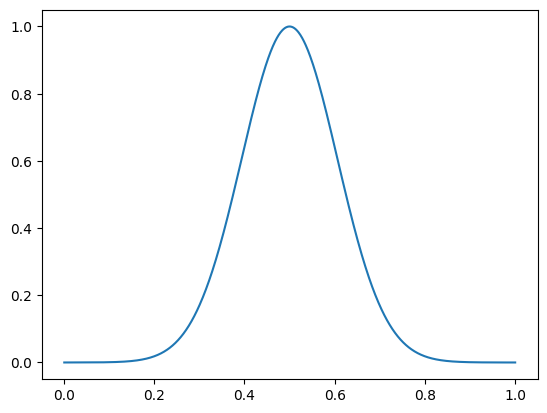

1.0000000000000007


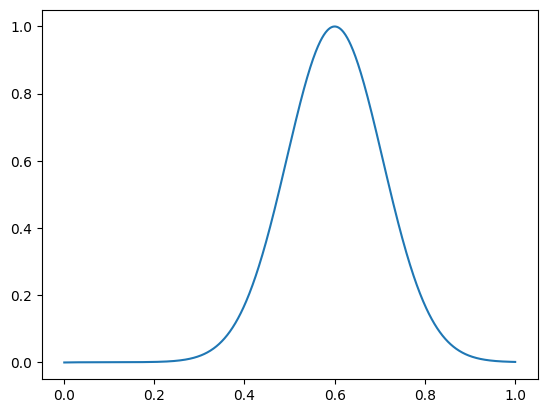

2.0009999999998906


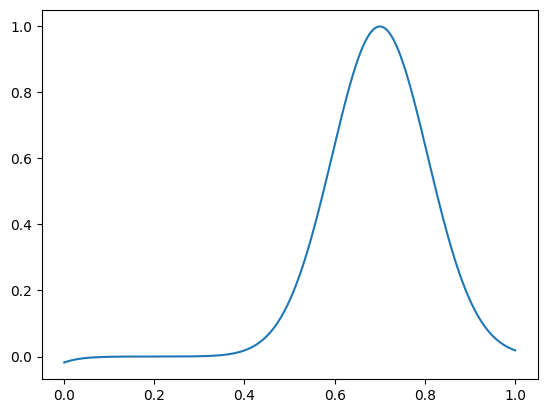

3.0009999999997805


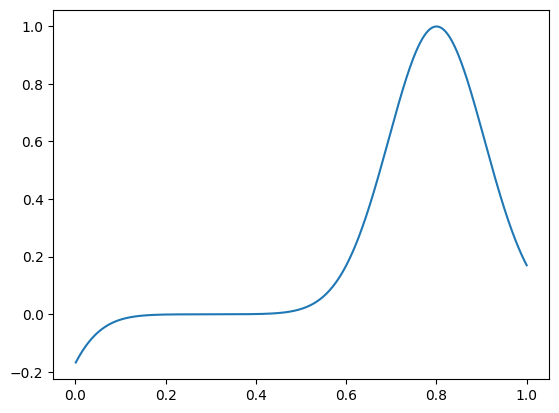

4.000999999999671


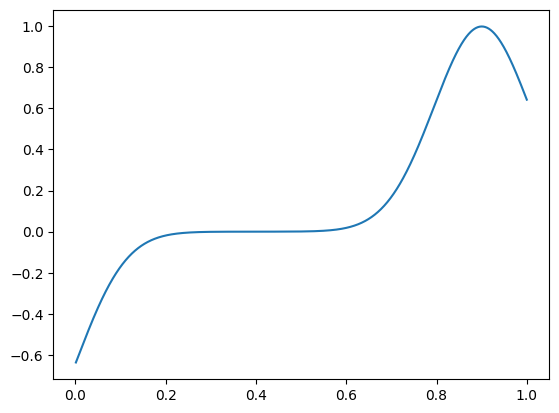

KeyboardInterrupt: 

In [2]:
#impli

import numpy as np
import matplotlib.pyplot as plt

dt = 0.001
start=0.0
stop=1.0
N=1000
u=0.1
tstop=10.4

dx   = (stop-start)/(N)
a    = u*dt/(2*dx)
xarr = np.linspace(start,stop,num=N+1)

rho0=np.exp(-1.0*((xarr[1:]-0.5)/0.15)**2) 

T_B=np.zeros((N,N))

T_B[0][N-1]=a
T_B[N-1][0]=-a
for i in range(0,N):
    T_B[i][i]=1
    if(i>0):
        T_B[i][i-1]=-a
    if(i<N-1):
        T_B[i][i+1]=a
    
T_B_inv = np.linalg.inv(T_B)

time=0.0
while (time<=tstop):
    rho1 = np.matmul(T_B_inv,rho0)
    if (time%1.0 < 1.0E-3):
        print(time)
        plt.plot(xarr[1:],rho1)
        plt.show()
    rho0=np.copy(rho1)
    time = time+dt

#plt.plot(xarr, rho0)
#plt.show()

  # vhalf = 0.5*(v0[:-1]+v0[1:])-(dt/(4*dx))*(v0[1:]**2-v0[:-1]**2)
  # #calculate full step
  # v1[1:-1] = v0[1:-1]-(0.5*dt/dx)*(vhalf[1:]**2-vhalf[:-1]**2)
  
  #   #applying periodic boundary conditions
  # v1[0] = v1[-2]
  # v1[-1]=v1[1]

0.0


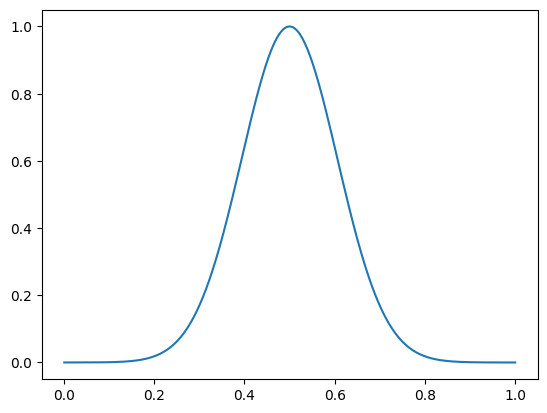

1.0000000000000007


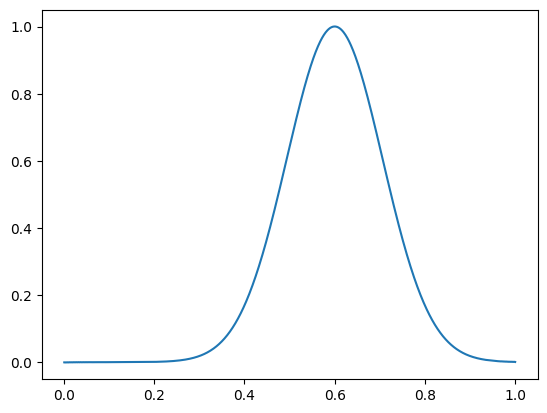

2.0009999999998906


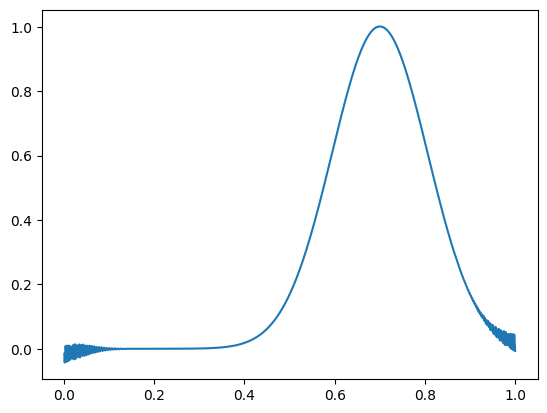

3.0009999999997805


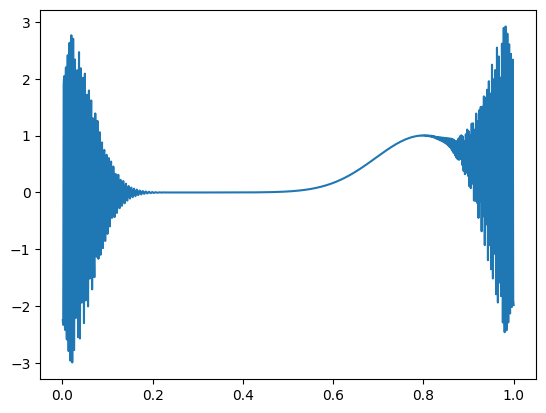

4.000999999999671


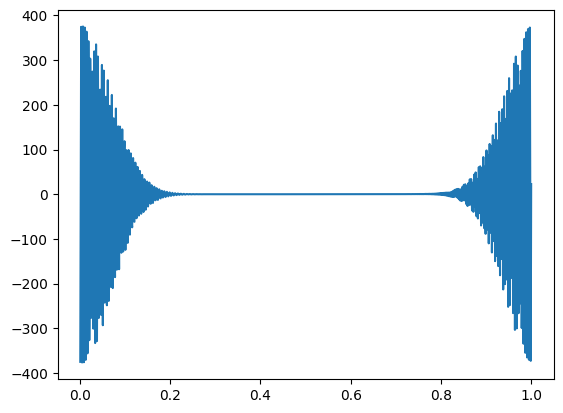

5.000000000000004


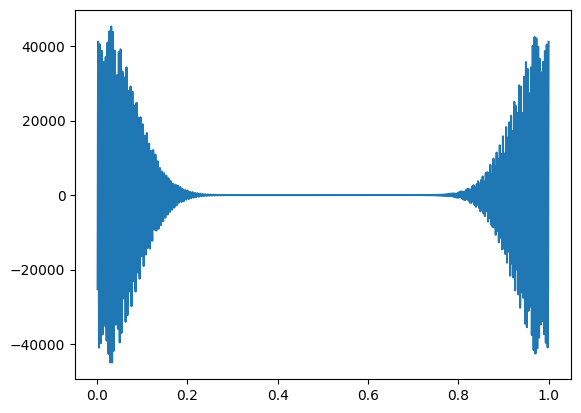

6.000000000000338


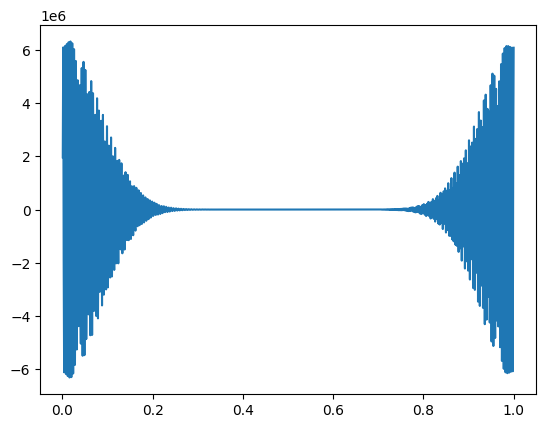

7.000000000000672


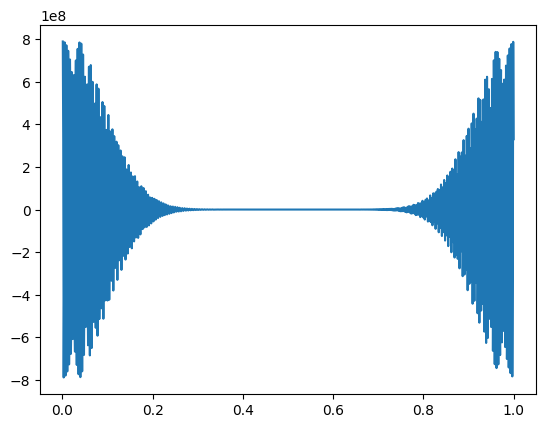

8.000000000001005


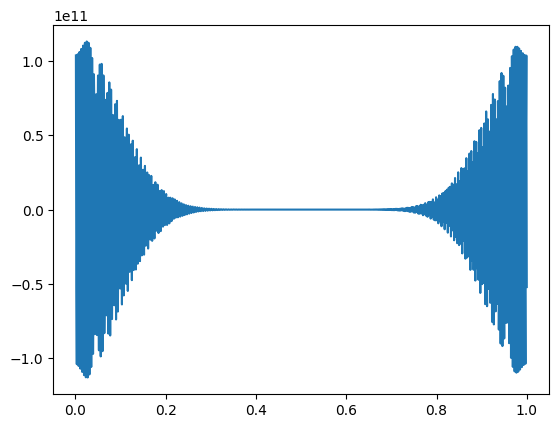

9.000000000000451


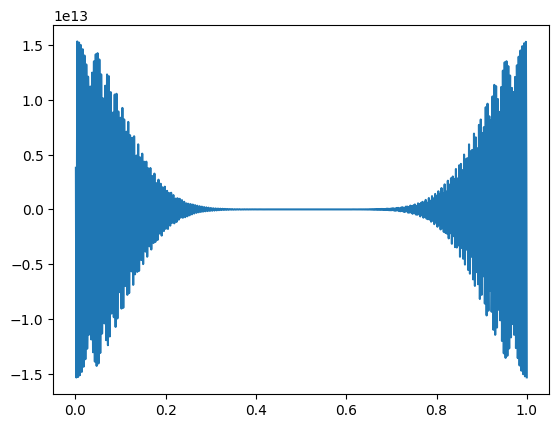

ValueError: x and y must have same first dimension, but have shapes (1001,) and (1000,)

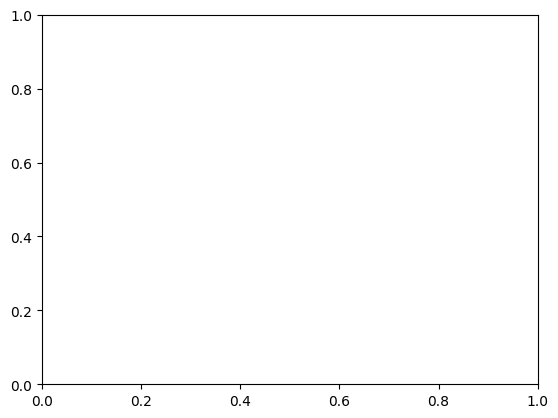

In [1]:

import numpy as np
import matplotlib.pyplot as plt

dt = 0.001
start=0.0
stop=1.0
N=1000
u=0.1
tstop=10

dx   = (stop-start)/(N)
a    = u*dt/(2*dx)
xarr = np.linspace(start,stop,num=N+1)

rho0=np.exp(-1.0*((xarr[1:]-0.5)/0.15)**2) 

T_B=np.zeros((N,N))

T_B[0][N-1]=-a
T_B[N-1][0]=a
for i in range(0,N):
    T_B[i][i]=1
    if(i>0):
        T_B[i][i-1]=a
    if(i<N-1):
        T_B[i][i+1]=-a
    

time=0.0
while (time<=tstop):
    rho1 = np.matmul(T_B,rho0)
    if (time%1.0 < 1.0E-3):
        print(time)
        plt.plot(xarr[1:],rho1)
        plt.show()
    rho0=np.copy(rho1)
    time = time+dt

plt.plot(xarr, rho0)
plt.show()

0.12441951103325913
[[-128.19717429   65.09729813    0.         ...    0.
     0.            0.        ]
 [  63.60887538 -128.19717429   65.58829891 ...    0.
     0.            0.        ]
 [   0.           63.1331758  -128.19717429 ...    0.
     0.            0.        ]
 ...
 [   0.            0.            0.         ... -128.19717429
    63.1331758     0.        ]
 [   0.            0.            0.         ...   65.58829891
  -128.19717429   63.60887538]
 [   0.            0.            0.         ...    0.
    65.09729813 -128.19717429]]
[-0.08859015 -0.17446203 -0.25508238 -0.328265   -0.39229116 -0.44597725
 -0.48868719 -0.52029561 -0.54111356 -0.55179153 -0.55321464 -0.5464023
 -0.53242118 -0.51231625 -0.48706119 -0.45752701 -0.42446596 -0.38850722
 -0.35016108 -0.30982836 -0.26781276 -0.22433448 -0.17954387 -0.13353462
 -0.08635619 -0.03802573  0.01146038  0.06211482  0.11394684  0.16694858
  0.22107939  0.27624782  0.33229086  0.38895053  0.44584828  0.50245855
  0.5580836

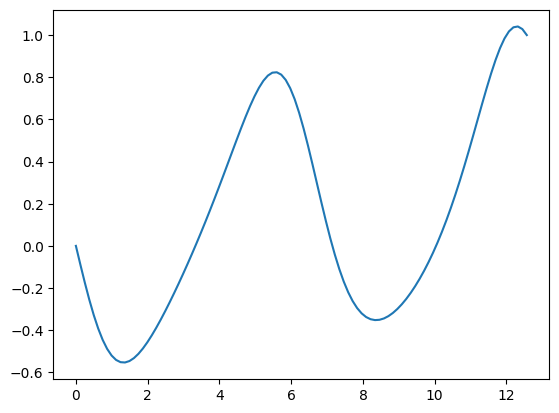

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv

def p_func(x):
    return np.sin(x)

def q_func(x):
    return 1.0+0.0*x

def s_func(x):
    return 0.0+0.0*x

#define number of internal points
N=100
a=0
b=4.0*np.pi

#boundary condition
fa = 0.0
fb = 1.0

dx = (b-a)/(N+1)

print(dx)

#define the x grid array
xgrid = np.linspace(a,b,num=N+2)

p_arr = p_func(xgrid)
q_arr = q_func(xgrid)
s_arr = s_func(xgrid)

#create D, S, and B matrices
S_mat = s_arr[1:N+1]

B_mat = np.zeros(N)
B_mat[0] = ((1/dx**2)-p_arr[1]/(2*dx))*fa
B_mat[-1] = ((1/dx**2)+p_arr[N]/(2*dx))*fb 

D_mat = np.zeros([N,N])

for i in range(0,N):
    D_mat[i,i] = q_arr[i+1]-(2/dx**2)
    if (i<N-1):
        D_mat[i,i+1] = (1/dx**2) + p_arr[i+1]/(2*dx)
    if (i>0):
        D_mat[i,i-1] = (1/dx**2) -p_arr[i+1]/(2*dx)
    
print(D_mat)


Dinv = inv(D_mat)

F_mat = np.matmul(Dinv,(S_mat-B_mat))

print(F_mat)

f_arr = np.zeros(N+2)
f_arr[0] = fa
f_arr[1:N+1] = F_mat
f_arr[N+1] = fb

plt.plot(xgrid, f_arr)
plt.show()
